In [112]:
import os
import warnings

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.weightstats import ztest

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from scipy import stats
from scipy.stats import chi2_contingency, f_oneway
import statsmodels.api as sm
from statsmodels.stats.weightstats import ztest

import joblib

warnings.filterwarnings("ignore")

In [4]:
base_dir = "drug_test_project"

raw_dir = os.path.join(base_dir, "data", "raw")
clean_dir = os.path.join(base_dir, "data", "cleaned")

plot_dir = os.path.join(base_dir, "outputs", "plots")
result_dir = os.path.join(base_dir, "outputs", "results")
model_dir = os.path.join(base_dir, "outputs", "model")

for folder in [raw_dir, clean_dir, plot_dir, result_dir, model_dir]:
    os.makedirs(folder, exist_ok=True)

print("Folders Created Successfully")

Folders Created Successfully


In [82]:
data = {
    "Age": [45, 50, 42, 48, 52, 46, 44, 49, 51],
    "Gender": ["M", "F", "M", "F", "M", "F", "M", "F", "M"],
    "Treatment": ["A", "A", "A", "B", "B", "B", "C", "C", "C"],
    "BP_Before": [150, 160, 145, 155, 165, 150, 158, 162, 170],
    "BP_After": [135, 140, 130, 125, 130, 120, 118, 122, 125],
    "PainScore": [3, 2, 4, 1, 2, 1, 1, 2, 1],
    "RecoveryDays": [10, 12, 9, 7, 8, 6, 5, 6, 5],
    "Recovered": ["No", "No", "No", "Yes", "No", "Yes", "Yes", "Yes", "Yes"],
}

df = pd.DataFrame(data)

df["BP_Reduction"] = df["BP_Before"] - df["BP_After"]

In [83]:
df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
0,45,M,A,150,135,3,10,No,15
1,50,F,A,160,140,2,12,No,20
2,42,M,A,145,130,4,9,No,15
3,48,F,B,155,125,1,7,Yes,30
4,52,M,B,165,130,2,8,No,35
5,46,F,B,150,120,1,6,Yes,30
6,44,M,C,158,118,1,5,Yes,40
7,49,F,C,162,122,2,6,Yes,40
8,51,M,C,170,125,1,5,Yes,45


In [84]:
try:
    raw_path = os.path.join(raw_dir, "raw_data.csv")
    df.to_csv(raw_path, index=False)
    print("raw data saved")
except Exception as e:
    print("Error :", e)

raw data saved


In [85]:
df.shape

(9, 9)

In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           9 non-null      int64
 1   Gender        9 non-null      str  
 2   Treatment     9 non-null      str  
 3   BP_Before     9 non-null      int64
 4   BP_After      9 non-null      int64
 5   PainScore     9 non-null      int64
 6   RecoveryDays  9 non-null      int64
 7   Recovered     9 non-null      str  
 8   BP_Reduction  9 non-null      int64
dtypes: int64(6), str(3)
memory usage: 780.0 bytes


In [87]:
df.describe(include="all")

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered,BP_Reduction
count,9.000000,9,9,9.000000,9.000000,9.000000,9.000000,9,9.00000
unique,NaN,2,3,NaN,NaN,NaN,NaN,2,NaN
top,NaN,M,A,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,5,3,NaN,NaN,NaN,NaN,5,NaN
mean,47.444444,NaN,NaN,157.222222,127.222222,1.888889,7.555556,NaN,30.00000
std,3.395258,NaN,NaN,8.012144,7.189885,1.054093,2.403701,NaN,11.18034
min,42.000000,NaN,NaN,145.000000,118.000000,1.000000,5.000000,NaN,15.00000
25%,45.000000,NaN,NaN,150.000000,122.000000,1.000000,6.000000,NaN,20.00000
50%,48.000000,NaN,NaN,158.000000,125.000000,2.000000,7.000000,NaN,30.00000
75%,50.000000,NaN,NaN,162.000000,130.000000,2.000000,9.000000,NaN,40.00000


In [88]:
df.duplicated()

0    False
1    False
2    False
3    False
4    False
5    False
6    False
7    False
8    False
dtype: bool

In [89]:
df.isnull().sum()

Age             0
Gender          0
Treatment       0
BP_Before       0
BP_After        0
PainScore       0
RecoveryDays    0
Recovered       0
BP_Reduction    0
dtype: int64

In [90]:
df.columns

Index(['Age', 'Gender', 'Treatment', 'BP_Before', 'BP_After', 'PainScore',
       'RecoveryDays', 'Recovered', 'BP_Reduction'],
      dtype='str')

In [91]:
for col in df.columns:
    uniques = df[col].unique()
    print(f"Unique values in '{col}': {uniques}")

Unique values in 'Age': [45 50 42 48 52 46 44 49 51]
Unique values in 'Gender': <StringArray>
['M', 'F']
Length: 2, dtype: str
Unique values in 'Treatment': <StringArray>
['A', 'B', 'C']
Length: 3, dtype: str
Unique values in 'BP_Before': [150 160 145 155 165 158 162 170]
Unique values in 'BP_After': [135 140 130 125 120 118 122]
Unique values in 'PainScore': [3 2 4 1]
Unique values in 'RecoveryDays': [10 12  9  7  8  6  5]
Unique values in 'Recovered': <StringArray>
['No', 'Yes']
Length: 2, dtype: str
Unique values in 'BP_Reduction': [15 20 30 35 40 45]


In [92]:
# # mapping (Label encoding) the categorical variables to numerical values
# for col in df.columns:
#     if df[col].dtype == "str":
#         df[col] = df[col].map(
#             {"M": 0, "F": 1, "A": 1, "B": 2, "C": 3, "No": 0, "Yes": 1}
#         )

# df

In [94]:
try:
    clean_path = os.path.join(clean_dir, "cleaned_data.csv")
    df.to_csv(clean_path, index=False)
    print("Cleaned Data Saved")
except Exception as e:
    print("Error :", e)

Cleaned Data Saved


array([[<Axes: title={'center': 'Age'}>,
        <Axes: title={'center': 'BP_Before'}>],
       [<Axes: title={'center': 'BP_After'}>,
        <Axes: title={'center': 'PainScore'}>],
       [<Axes: title={'center': 'RecoveryDays'}>,
        <Axes: title={'center': 'BP_Reduction'}>]], dtype=object)

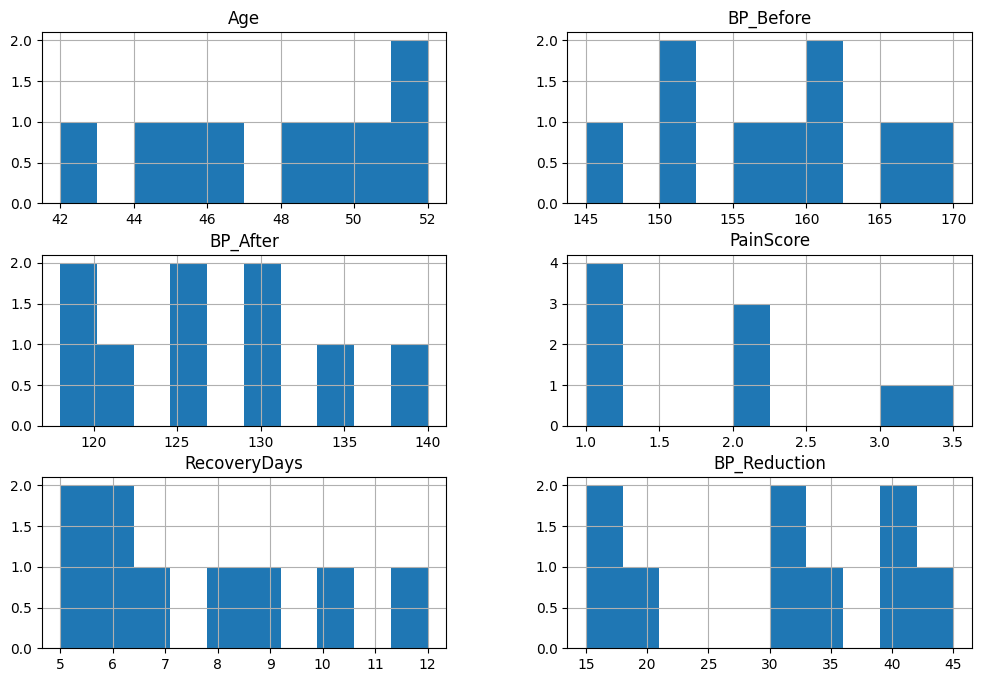

In [95]:
df.hist(figsize=(12, 8))

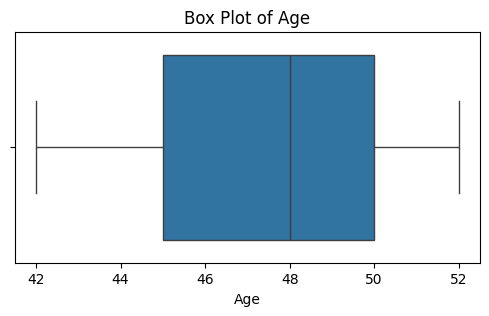

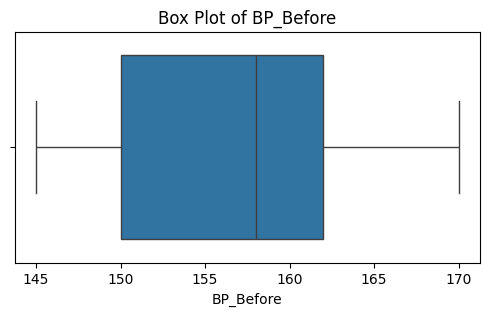

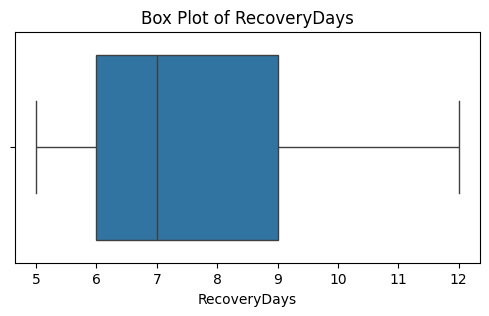

In [96]:
# outliers box plot for all numerical columns
for col in df[["Age", "BP_Before", "RecoveryDays"]].columns:
    plt.figure(figsize=(6, 3))
    sns.boxplot(x=df[col])
    plt.title(f"Box Plot of {col}")
    plt.savefig(os.path.join(plot_dir, f"boxplot_{col}.png"), bbox_inches="tight")
    plt.show()

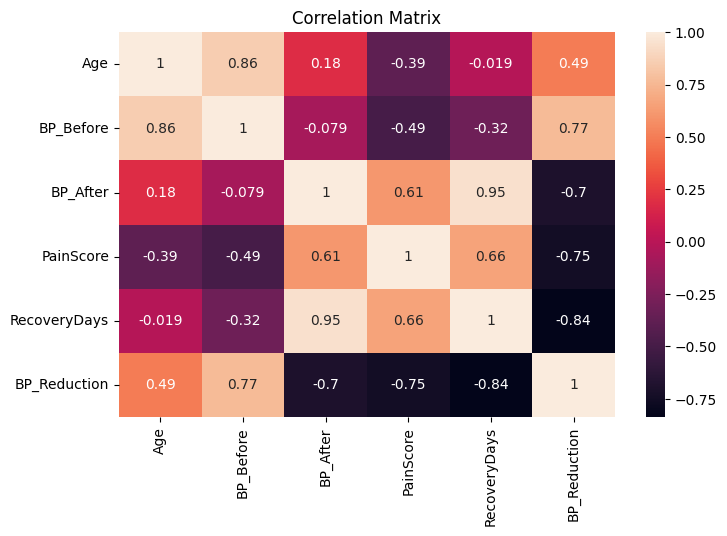

In [97]:
try:
    plt.figure(figsize=(8, 5))
    sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True)
    plt.title("Correlation Matrix")
    plt.savefig(os.path.join(plot_dir, "correlation_Matrix.png"))
    plt.show()
except Exception as e:
    print(e)

In [ ]:
# Higher BP After Treatment → Longer Recovery Time
# Higher Pain Score → Longer Recovery Time
# Higher BP Reduction → Faster Recovery
# Higher BP Reduction → Lower Pain Score


In [ ]:
# testing
z_stat, p_value = ztest(df["BP_Reduction"], value=0, alternative="larger")

print("Z-test")
print("z-statistic:", z_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: significant")
else:
    print("Result: not significant")

Z-test
z-statistic: 8.049844718999243
p-value: 4.144957337186113e-16
Result: significant


In [ ]:
# t-test, is mean BP_Reduction greater than 0?
t_stat, p_value = stats.ttest_1samp(
    df["BP_Reduction"], popmean=0, alternative="greater"
)

print("T-test")
print("t-statistic:", t_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: significant")
else:
    print("Result: not significant")

T-test
t-statistic: 8.049844718999243
p-value: 2.0878830813832884e-05
Result: significant


In [116]:
table = pd.crosstab(df["Treatment"], df["Recovered"])

chi2, p_value, dof, expected = chi2_contingency(table)

print("Chi-square test")
print("chi2:", chi2)
print("p-value:", p_value)
print("degrees of freedom:", dof)

if p_value < 0.05:
    print("Result: treatment and recovery are related")
else:
    print("Result: no clear relation")

Chi-square test
chi2: 6.300000000000001
p-value: 0.04285212686704016
degrees of freedom: 2
Result: treatment and recovery are related


In [114]:
a = df[df["Treatment"] == "A"]["BP_Reduction"]
b = df[df["Treatment"] == "B"]["BP_Reduction"]
c = df[df["Treatment"] == "C"]["BP_Reduction"]

f_stat, p_value = f_oneway(a, b, c)

print("ANOVA")
print("F-statistic:", f_stat)
print("p-value:", p_value)

if p_value < 0.05:
    print("Result: at least one treatment is different")
else:
    print("Result: all treatments look similar")

ANOVA
F-statistic: 56.99999999999999
p-value: 0.00012500000000000003
Result: at least one treatment is different


In [ ]:
result = df.groupby("Treatment").agg(
    mean_bp_reduction=("BP_Reduction", "mean"),
    mean_recovery_days=("RecoveryDays", "mean"),
    recovery_rate=("Recovered", lambda x: (x == "Yes").mean()),
)

print(result)

best_treatment = result["mean_bp_reduction"].idxmax()
print("\nBest treatment by BP reduction:", best_treatment)

           mean_bp_reduction  mean_recovery_days  recovery_rate
Treatment                                                      
A                  16.666667           10.333333       0.000000
B                  31.666667            7.000000       0.666667
C                  41.666667            5.333333       1.000000

Best treatment by BP reduction: C


In [118]:
from sklearn.preprocessing import LabelEncoder

In [119]:
le_gender = LabelEncoder()
le_recovered = LabelEncoder()
le_treatment = LabelEncoder()

df["Gender"] = le_gender.fit_transform(df["Gender"])
df["Recovered"] = le_recovered.fit_transform(df["Recovered"])
df["Treatment"] = le_treatment.fit_transform(df["Treatment"])

In [145]:
# training
X = df[
    [
        "Age",
        "Gender",
        "Treatment",
        "BP_Before",
        "BP_After",
        "PainScore",
        "RecoveryDays"
    ]
]
y = df["Recovered"]

In [146]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

In [147]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

try:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    lr_model = LogisticRegression()

    lr_model.fit(X_train_scaled, y_train)

    lr_pred = lr_model.predict(X_test_scaled)

    lr_acc = accuracy_score(y_test, lr_pred)

    print("Logistic Regression Accuracy :", lr_acc)

    print(classification_report(y_test, lr_pred))

except Exception as e:

    print(e)

Logistic Regression Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [148]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

try:

    dt_model = DecisionTreeClassifier(random_state=42)

    dt_model.fit(X_train, y_train)

    dt_pred = dt_model.predict(X_test)

    dt_acc = accuracy_score(y_test, dt_pred)

    print("Decision Tree Accuracy :", dt_acc)

    print(classification_report(y_test, dt_pred))

except Exception as e:

    print(e)

Decision Tree Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [149]:
from sklearn.ensemble import RandomForestClassifier

try:

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

    rf_model.fit(X_train, y_train)

    rf_pred = rf_model.predict(X_test)

    rf_acc = accuracy_score(y_test, rf_pred)

    print("Random Forest Accuracy :", rf_acc)

    print(classification_report(y_test, rf_pred))

except Exception as e:

    print(e)

Random Forest Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [ ]:
from sklearn.neighbors import KNeighborsClassifier

try:

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)

    X_test_scaled = scaler.transform(X_test)

    knn_model = KNeighborsClassifier(n_neighbors=3)

    knn_model.fit(X_train_scaled, y_train)

    knn_pred = knn_model.predict(X_test_scaled)

    knn_acc = accuracy_score(y_test, knn_pred)

    print("KNN Accuracy :", knn_acc)

    print(classification_report(y_test, knn_pred))

except Exception as e:

    print(e)

KNN Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [159]:
try:

    new_patient = pd.DataFrame({

        "Age":[47],
        "Gender":[1],
        "Treatment":[2],
        "BP_Before":[160],
        "BP_After":[130],
        "PainScore":[2],
        "RecoveryDays":[7],
    })

    prediction = rf_model.predict(new_patient)
    
    result = "Recovered" if prediction[0] == 1 else "Not Recovered"
    print("Patient", result)
except Exception as e:

    print(e)

Patient Recovered
